# ANIP - Tâche 2 : Estimation de l'Âge
## Age Estimation from Photos

Ce notebook implémente un modèle d'estimation d'âge basé sur des photos de visages.

## 1. Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

print("🎯 ANIP - Tâche 2: Estimation de l'Âge\n")

2025-10-15 16:20:19.041437: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🎯 ANIP - Tâche 2: Estimation de l'Âge



In [2]:
# Configuration
DATA_PATH = Path('anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_2/dataset_tache_2')
TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH = DATA_PATH / 'test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Parsing des Noms de Fichiers

In [3]:
def parse_train_filename(filepath):
    """
    Parse le nom de fichier du train set
    Format: XXXXXX_YZWW.jpg où:
    - XXXXXX = person_id
    - Y = photo_num (0, 1, 2, ...)
    - Z = gender (M/F)
    - WW = age (00-99)
    
    Exemples:
    - 00013_00M19.JPG → person_id=13, photo=0, gender=M, age=19
    - 00022_03M19.JPG → person_id=22, photo=3, gender=M, age=19
    """
    filename = filepath.stem
    
    # Pattern pour extraire les informations
    match = re.search(r'(\d+)_(\d+)([MF])(\d{2})', filename)
    
    if match:
        person_id = int(match.group(1))
        photo_num = int(match.group(2))
        gender = match.group(3)  # 'M' ou 'F'
        age = int(match.group(4))
        return person_id, photo_num, gender, age
    
    return None, None, None, None

## 3. Chargement des Données

In [4]:
def load_train_data(train_path):
    """Charge et parse les données d'entraînement"""
    print("📂 Chargement des données d'entraînement...")
    
    # Trouver toutes les images
    image_paths = list(train_path.glob('*.jpg')) + list(train_path.glob('*.JPG'))
    
    data = []
    skipped = 0
    
    for img_path in tqdm(image_paths):
        person_id, photo_num, gender, age = parse_train_filename(img_path)
        
        if age is not None:
            data.append({
                'filepath': str(img_path),
                'filename': img_path.name,
                'person_id': person_id,
                'photo_num': photo_num,
                'gender': gender,
                'gender_encoded': 1 if gender == 'M' else 0,  # M=1, F=0
                'age': age
            })
        else:
            skipped += 1
    
    df = pd.DataFrame(data)
    
    if skipped > 0:
        print(f"⚠️  {skipped} fichiers ignorés (format non reconnu)")
    
    return df

# Charger les données
df_train = load_train_data(TRAIN_PATH)

print(f"\n✅ Données chargées: {len(df_train)} images")
print(f"   Personnes uniques: {df_train['person_id'].nunique()}")
print(f"   Répartition par sexe:")
print(df_train['gender'].value_counts())

📂 Chargement des données d'entraînement...


100%|██████████| 40012/40012 [00:00<00:00, 98630.93it/s]



✅ Données chargées: 40012 images
   Personnes uniques: 17417
   Répartition par sexe:
gender
M    34433
F     5579
Name: count, dtype: int64


## 4. Analyse Exploratoire

In [5]:
print("\n📊 Statistiques des âges:")
print(f"   Moyenne: {df_train['age'].mean():.1f} ans")
print(f"   Médiane: {df_train['age'].median():.1f} ans")
print(f"   Min: {df_train['age'].min()} ans")
print(f"   Max: {df_train['age'].max()} ans")

# Distribution par décennies
print(f"\n📊 Distribution par décennies:")
decades = pd.cut(df_train['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 100])
print(decades.value_counts().sort_index())

# Distribution par sexe et âge
print(f"\n📊 Âge moyen par sexe:")
print(df_train.groupby('gender')['age'].mean())


📊 Statistiques des âges:
   Moyenne: 32.9 ans
   Médiane: 33.0 ans
   Min: 16 ans
   Max: 77 ans

📊 Distribution par décennies:
age
(0, 10]          0
(10, 20]      6470
(20, 30]     11326
(30, 40]     11480
(40, 50]      8267
(50, 60]      2273
(60, 70]       189
(70, 100]        7
Name: count, dtype: int64

📊 Âge moyen par sexe:
gender
F    33.432336
M    32.778410
Name: age, dtype: float64



✅ Visualisation EDA sauvegardée: tache2_eda.png


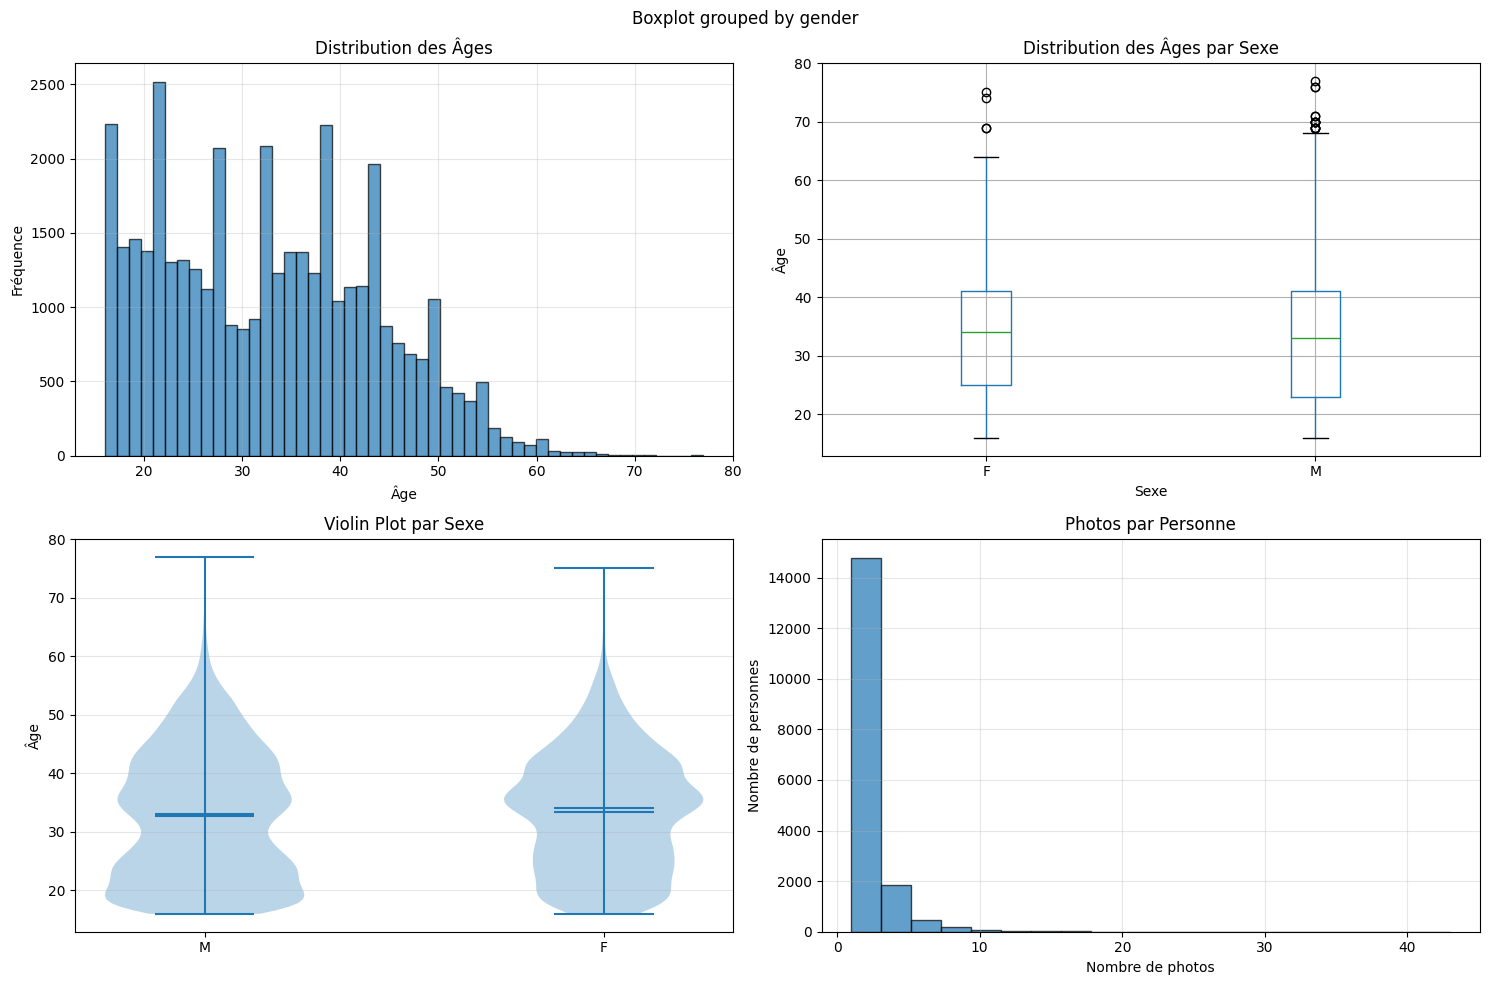

In [6]:
# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme des âges
axes[0, 0].hist(df_train['age'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Âge')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des Âges')
axes[0, 0].grid(True, alpha=0.3)

# Box plot par sexe
df_train.boxplot(column='age', by='gender', ax=axes[0, 1])
axes[0, 1].set_title('Distribution des Âges par Sexe')
axes[0, 1].set_xlabel('Sexe')
axes[0, 1].set_ylabel('Âge')

# Violin plot
parts = axes[1, 0].violinplot([df_train[df_train['gender']=='M']['age'],
                                df_train[df_train['gender']=='F']['age']],
                               positions=[1, 2], showmeans=True, showmedians=True)
axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(['M', 'F'])
axes[1, 0].set_ylabel('Âge')
axes[1, 0].set_title('Violin Plot par Sexe')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Nombre de photos par personne
photos_per_person = df_train.groupby('person_id').size()
axes[1, 1].hist(photos_per_person, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Nombre de photos')
axes[1, 1].set_ylabel('Nombre de personnes')
axes[1, 1].set_title('Photos par Personne')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tache2_eda.png', dpi=150, bbox_inches='tight')
print("\n✅ Visualisation EDA sauvegardée: tache2_eda.png")

## 5. Préparation des Données

In [7]:
def load_and_preprocess_image(image_path, img_size=IMG_SIZE):
    """Charge et prétraite une image"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img.astype('float32') / 255.0
    return img

def data_generator(df, batch_size=32, img_size=IMG_SIZE, 
                   augment=False, use_gender=False):
    """Générateur de données pour l'entraînement"""
    n_samples = len(df)
    indices = np.arange(n_samples)
    
    while True:
        np.random.shuffle(indices)
        
        for start_idx in range(0, n_samples, batch_size):
            batch_indices = indices[start_idx:start_idx+batch_size]
            batch_df = df.iloc[batch_indices]
            
            # Charger les images
            batch_images = []
            for filepath in batch_df['filepath']:
                img = load_and_preprocess_image(filepath, img_size)
                
                # Augmentation de données basique
                if augment and np.random.random() > 0.5:
                    # Flip horizontal
                    if np.random.random() > 0.5:
                        img = np.fliplr(img)
                    # Ajustement de luminosité
                    if np.random.random() > 0.5:
                        factor = np.random.uniform(0.8, 1.2)
                        img = np.clip(img * factor, 0, 1)
                
                batch_images.append(img)
            
            batch_images = np.array(batch_images)
            batch_ages = batch_df['age'].values
            
            if use_gender:
                batch_gender = batch_df['gender_encoded'].values
                yield [batch_images, batch_gender], batch_ages
            else:
                yield batch_images, batch_ages

In [8]:
# Split train/validation
train_df, val_df = train_test_split(df_train, test_size=0.15, random_state=SEED)

print(f"\n📊 Split des données:")
print(f"   Train: {len(train_df)} images")
print(f"   Validation: {len(val_df)} images")


📊 Split des données:
   Train: 34010 images
   Validation: 6002 images


## 6. Création du Modèle

In [9]:
def create_age_model(input_shape=(224, 224, 3), use_gender=False):
    """
    Crée un modèle pour l'estimation d'âge
    Option: intégrer le genre comme feature
    """
    
    # Base model
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False
    
    # Input
    image_input = layers.Input(shape=input_shape, name='image_input')
    
    # Feature extraction
    x = base_model(image_input)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    # Option: ajouter le genre
    if use_gender:
        gender_input = layers.Input(shape=(1,), name='gender_input')
        x = layers.Concatenate()([x, gender_input])
        inputs = [image_input, gender_input]
    else:
        inputs = image_input
    
    # Fully connected layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Output: âge (régression)
    output = layers.Dense(1, activation='linear', name='age_output')(x)
    
    # Créer le modèle
    model = models.Model(inputs=inputs, outputs=output)
    
    return model

In [10]:
# Créer le modèle (sans genre pour simplifier)
USE_GENDER = False
print(f"\n🧠 Création du modèle (use_gender={USE_GENDER})...")

model = create_age_model(use_gender=USE_GENDER)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae', 'mse']
)

print("✅ Modèle créé")
model.summary()


🧠 Création du modèle (use_gender=False)...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
✅ Modèle créé


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ age_output (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,068 (16.83 MB)

 Trainable params: 361,729 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

## 7. Callbacks

In [12]:
callbacks = [
       ModelCheckpoint(
        'best_age_model_tache2.keras',
        monitor='val_mae',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_mae',
        patience=8,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=4,
        mode='min',
        min_lr=1e-7,
        verbose=1
    )
]

## 8. Entraînement

In [13]:
print(f"\n🎯 Entraînement du modèle ({EPOCHS} epochs)...")

steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE

train_gen = data_generator(train_df, BATCH_SIZE, augment=True, use_gender=USE_GENDER)
val_gen = data_generator(val_df, BATCH_SIZE, augment=False, use_gender=USE_GENDER)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Entraînement terminé!")


🎯 Entraînement du modèle (30 epochs)...
Epoch 1/30
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 21.7941 - mae: 21.7941 - mse: 665.4478
Epoch 1: val_mae improved from inf to 9.97652, saving model to best_age_model_tache2.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 1993s 2s/step - loss: 21.7873 - mae: 21.7873 - mse: 665.1485 - val_loss: 9.9765 - val_mae: 9.9765 - val_mse: 151.0448 - learning_rate: 0.0010
Epoch 2/30
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 9.6002 - mae: 9.6002 - mse: 132.1888
Epoch 2: val_mae improved from 9.97652 to 9.19554, saving model to best_age_model_tache2.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 2167s 2s/step - loss: 9.6002 - mae: 9.6002 - mse: 132.1885 - val_loss: 9.1955 - val_mae: 9.1955 - val_mse: 117.3491 - learning_rate: 0.0010
Epoch 3/30
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 9.5401 - mae: 9.5401 - mse: 129.5461
Epoch 3: val_mae improved from 9.19554 to 9.19452, saving model to best_age_model_tache2.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 2173s 2

✅ Historique d'entraînement sauvegardé


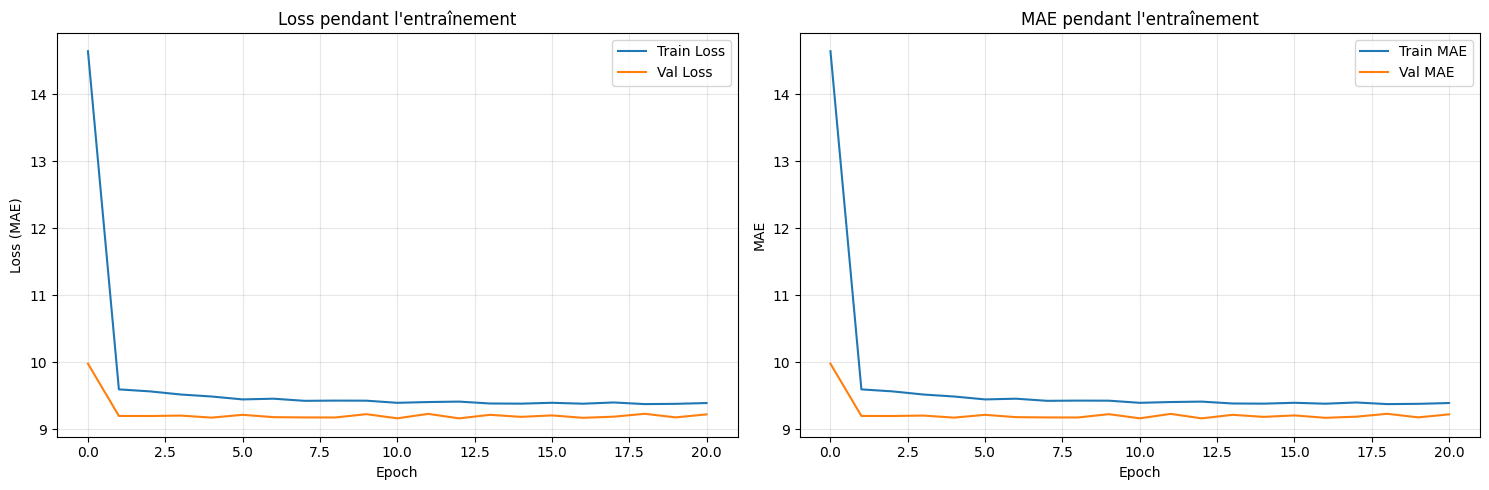

In [14]:
# Visualiser l'entraînement
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MAE)')
axes[0].legend()
axes[0].set_title('Loss pendant l\'entraînement')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].set_title('MAE pendant l\'entraînement')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tache2_training_history.png', dpi=150, bbox_inches='tight')
print("✅ Historique d'entraînement sauvegardé")

## 9. Prédiction sur le Test Set

In [15]:
print("\n🔮 Prédictions sur le test set...")

# Charger les images de test
test_images = list(TEST_PATH.glob('*.jpg')) + list(TEST_PATH.glob('*.JPG'))
print(f"   Images de test: {len(test_images)}")

# Prédire
predictions = []
filenames = []

for img_path in tqdm(test_images):
    img = load_and_preprocess_image(str(img_path))
    
    if USE_GENDER:
        # Si on utilise le genre, il faudrait le deviner ou utiliser un modèle
        gender = 0  # Par défaut
        pred = model.predict([np.expand_dims(img, axis=0), 
                             np.array([[gender]])], verbose=0)[0][0]
    else:
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]
    
    predictions.append(pred)
    filenames.append(img_path.stem)  # Sans extension

predictions = np.array(predictions)

# Clipper les prédictions dans une plage raisonnable
predictions = np.clip(predictions, 0, 100)

print(f"\n✅ Prédictions effectuées")
print(f"   Âge moyen prédit: {predictions.mean():.1f} ans")
print(f"   Min: {predictions.min():.1f}, Max: {predictions.max():.1f}")


🔮 Prédictions sur le test set...
   Images de test: 200


100%|██████████| 200/200 [00:23<00:00,  8.53it/s]


✅ Prédictions effectuées
   Âge moyen prédit: 33.3 ans
   Min: 33.2, Max: 33.3


## 10. Création du Fichier de Soumission

In [16]:
# Créer le DataFrame de soumission
submission = pd.DataFrame({
    'image_id': filenames,
    'predicted_age': np.round(predictions, 2)
})

# Trier par image_id (numérique)
submission['image_id_num'] = submission['image_id'].astype(int)
submission = submission.sort_values('image_id_num')
submission = submission[['image_id', 'predicted_age']]

# Sauvegarder
submission.to_csv('tache2_submission.csv', index=False)

print(f"\n✅ Soumission sauvegardée: tache2_submission.csv")
print(f"\n📊 Aperçu:")
print(submission.head(10))


✅ Soumission sauvegardée: tache2_submission.csv

📊 Aperçu:
    image_id  predicted_age
196        0      33.270000
186        1      33.299999
163        2      33.279999
177        3      33.230000
121        4      33.279999
135        5      33.240002
159        6      33.250000
139        7      33.270000
36         8      33.250000
49         9      33.270000


✅ Distribution des prédictions sauvegardée


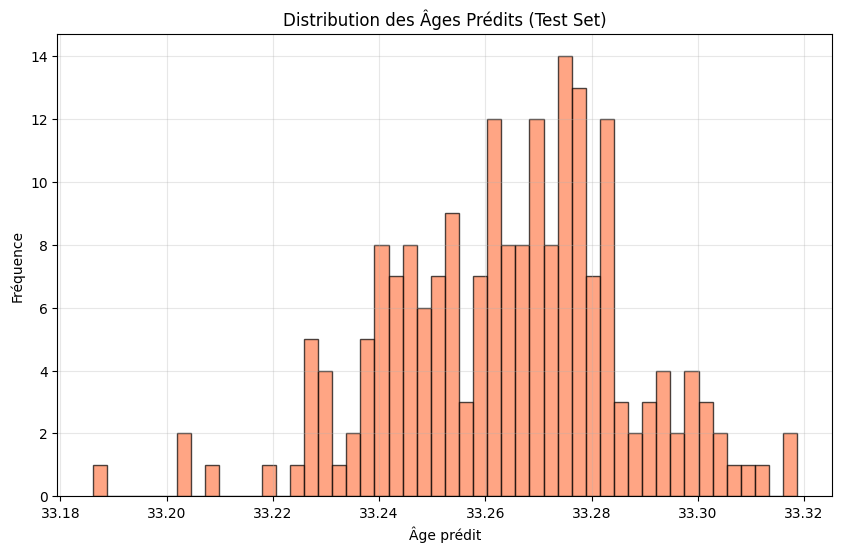

In [17]:
# Visualiser la distribution des prédictions
plt.figure(figsize=(10, 6))
plt.hist(predictions, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Âge prédit')
plt.ylabel('Fréquence')
plt.title('Distribution des Âges Prédits (Test Set)')
plt.grid(True, alpha=0.3)
plt.savefig('tache2_predictions_distribution.png', dpi=150, bbox_inches='tight')
print("✅ Distribution des prédictions sauvegardée")

## Résumé et Prochaines Étapes

In [18]:
print("\n" + "="*70)
print("✅ TÂCHE 2 TERMINÉE!")
print("="*70)
print(f"\nFichiers générés:")
print(f"  1. tache2_submission.csv")
print(f"  2. best_age_model_tache2.keras")
print(f"  3. tache2_eda.png")
print(f"  4. tache2_training_history.png")
print(f"  5. tache2_predictions_distribution.png")
print(f"\nProchaines étapes pour améliorer:")
print(f"  - Utiliser le genre comme feature additionnelle")
print(f"  - Essayer différents modèles (ResNet, EfficientNetB3)")
print(f"  - Augmentation de données plus agressive")
print(f"  - Fine-tuning du modèle de base")
print(f"  - Ensemble de plusieurs modèles")


✅ TÂCHE 2 TERMINÉE!

Fichiers générés:
  1. tache2_submission.csv
  2. best_age_model_tache2.keras
  3. tache2_eda.png
  4. tache2_training_history.png
  5. tache2_predictions_distribution.png

Prochaines étapes pour améliorer:
  - Utiliser le genre comme feature additionnelle
  - Essayer différents modèles (ResNet, EfficientNetB3)
  - Augmentation de données plus agressive
  - Fine-tuning du modèle de base
  - Ensemble de plusieurs modèles
